![KAUST Academy](https://i.imgur.com/a3uAqnb.png)

# Lab 6 — Large Reasoning Models
### From *"let's think step by step"* to GRPO and GSPO


## 🗺️ The roadmap — one question, chased for eight parts

We start from a single uncomfortable observation and keep pulling the thread:

> *An LLM can write a fluent paragraph about the Pythagorean theorem, but gets `17 × 24` wrong.
> **What is missing, and how do we put it in?***

| Part | The question it answers | You will build |
| :--- | :--- | :--- |
| **1** | Is it reasoning, or is it pattern matching? | The vocabulary: LLM vs LRM |
| **2** | Can we get reasoning for free, at inference time? | Chain-of-Thought, **self-consistency voting** |
| **3** | If a model reasons, how do we *score* it? | A **rule-based math verifier** (`math_reward`) |
| **4** | How do we turn that score into a weight update? | **GRPO** group-relative advantages |
| **5** | Why does GRPO break on long traces and MoE models? | **GSPO** sequence-level ratios (with a variance demo) |
| **6** | Does any of this survive contact with a real model? | Live **Qwen3** thinking-toggle experiment |
| **7** | Can we trust the reasoning we just bought? | The failure cases — faithfulness and collapse |
| **8** | What do I actually take away? | Recap, exercises, references |

**Parts 1–5 and 7 run on CPU in seconds.** Only **Part 6** needs a GPU.

---

## 📦 Step 0.1 — Install the libraries

Four packages, and each earns its place:

| Package | Why this lab needs it |
| :--- | :--- |
| `torch` | Tensors for the GRPO/GSPO advantage maths |
| `transformers` | Loads Qwen3 and applies its **chat template** (Part 6) |
| `accelerate` | Handles `device_map="auto"` so the model lands on the GPU by itself |
| `matplotlib` | The accuracy comparison chart |

> 💡 **`-q` = quiet.** Colab installs are noisy; `-q` keeps the notebook readable.
> If a package is already present, `pip` skips it — re-running this cell is safe.

In [ ]:
# Install everything up front so no later cell fails on a missing import.
# !pip install -q torch transformers accelerate matplotlib numpy

## 📥 Step 0.2 — Imports and the reproducibility seed

Nothing exotic here, but read the seeding block carefully — it explains a trap you *will* hit in Part 6.

In [ ]:
# --- Standard library -------------------------------------------------
import re                          # regex: pulling the final answer out of model text
import random                      # Python's RNG (seeded below)
from collections import Counter    # majority voting in self-consistency
from typing import Optional        # type hints: a value that may legitimately be None

# --- Third party ------------------------------------------------------
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Reproducibility --------------------------------------------------
# Three independent random number generators can affect this notebook, so all three
# get the same seed. Miss one and your "identical" re-run silently diverges.
SEED = 42
random.seed(SEED)              # 1. Python's `random` module
np.random.seed(SEED)           # 2. NumPy
torch.manual_seed(SEED)        # 3. PyTorch (CPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)   # ...and every visible GPU

print(f"PyTorch      : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
else:
    print("GPU           : none — Parts 1-5 and 7 still run fine on CPU.")

PyTorch      : 2.11.0+cu128
CUDA available: True
GPU           : Tesla T4


# 🧠 Part 1 — Is it reasoning, or is it pattern matching?

## ❓ The question

Here are two prompts. A large language model gets the **first** right almost every time and the
**second** wrong surprisingly often:

1. *"What is the capital of France?"* → **Paris** ✅
2. *"Which is heavier: a kilogram of feathers or a kilogram of iron?"* → *"Iron is heavier"* ❌

Both are one-line questions. Both are about facts the model has certainly seen thousands of times.
**So why does the second one break?**

## 💡 The idea

Question 1 needs **retrieval**. The string `"capital of France is"` is followed by `"Paris"` millions
of times in the training data. The model reproduces a statistical association, and that is *enough*.

Question 2 needs **retrieval to be overridden**. The training data is soaked in
*iron → heavy* and *feathers → light*. To answer correctly the model must notice that the word
**"kilogram"** appears on both sides and makes the material irrelevant. That is a *step*, and steps
are exactly what a single forward pass through a Transformer does not naturally produce.

> **The one-sentence version:** pattern matching answers from the *surface* of the question;
> reasoning answers from its *structure*.

## 📗 The terms

> ### **Large Language Model (LLM)**
> A model trained to predict the next token. Optimised for **fluency and coverage** — it generates
> text that *looks* right. Fast, one forward pass per token, uniform compute for every query.
>
> ### **Large Reasoning Model (LRM)**
> An LLM further trained (and prompted) to **emit intermediate reasoning steps before its answer**.
> Optimised for **multi-step correctness**. Slower, spends more decode steps on a hard question
> than an easy one.

The distinction is *not* architectural. **An LRM is an LLM with different post-training and a
different inference-time habit.**

### The comparison, side by side

| | **LLM** | **LRM** |
| :--- | :--- | :--- |
| **Core function** | Fluent, human-like text | Solve problems needing logic |
| **Reasoning** | Limited; struggles with multi-step | Consistent, explicit steps |
| **Speed** | Fast — optimised for throughput | Slow — thinks before answering |
| **Compute per query** | Fixed | Scales with difficulty |
| **Best for** | High-volume, low-risk tasks | High-stakes tasks where the *why* matters |
| **Examples** | GPT-3, base LLaMA | o1/o3, DeepSeek-R1, QwQ, Gemini Flash Thinking, Claude extended thinking, Magistral |

## ➡️ Next

We've established that the ability is latent and the prompt unlocks it. So the obvious follow-up:

> **How far can we get with prompting alone, before we're forced to touch the weights?**

That's Part 2.

---

# 🌳 Part 2 — Reasoning for free: techniques that never touch the weights

## ❓ The question

Training is expensive. Prompting is nearly free. **How much reasoning can we buy without a single
gradient step?**

The answer, it turns out, is *a lot* — and the three techniques below form a natural ladder of
increasing cost.

## 📗 Technique 1 — Chain-of-Thought (CoT)

> ### **Chain-of-Thought prompting**
> Prompting the model to **emit intermediate reasoning steps before the final answer**, instead of
> answering directly.

**Why does this work at all?** A Transformer does a *fixed* amount of computation per token. If the
answer must appear in the very next token, the model has exactly one forward pass to do all the
work. Let it write ten tokens of working first, and it gets **ten forward passes**, each one able to
attend to the partial results of the last.

> 🔑 **The mental model that makes CoT click:**
> the generated tokens *are the scratchpad*. The model has no other working memory.
> Denying it output tokens is denying it the ability to compute.

### Two flavours

| | **Few-shot CoT** | **Zero-shot CoT** |
| :--- | :--- | :--- |
| **What's in the prompt** | Worked examples *with* their reasoning | Just the instruction *"Let's think step by step"* |
| **Cost** | Hand-writing exemplars per task | Free |


In [ ]:
print("Goal: You have 200 SAR.")
print("You spend 75 SAR on groceries and 40 SAR on fuel.")
print("How much money is left?\n")

# --------------------------------------------------
# 1) Zero-shot CoT
# --------------------------------------------------
print("=== Zero-shot CoT ===")
print('Prompt: "Let\'s think step by step."\n')

zero_shot_path = [
    "Start with 200 SAR",
    "200 - 75 = 125 SAR",
    "125 - 40 = 85 SAR",
]

for step in zero_shot_path:
    print(step)

print("\nFinal answer: 85 SAR ✅")


# --------------------------------------------------
# 2) Few-shot CoT
# --------------------------------------------------
print("\n=== Few-shot CoT ===")
print("Prompt contains a worked reasoning example first.\n")

print("Example:")
print("100 - 30 = 70")
print("Final answer: 70 SAR\n")

print("Now solve the new problem:")

few_shot_path = [
    "200 - 75 = 125 SAR",
    "125 - 40 = 85 SAR",
]

for step in few_shot_path:
    print(step)

print("\nFinal answer: 85 SAR ✅")

Goal: You have 200 SAR.
You spend 75 SAR on groceries and 40 SAR on fuel.
How much money is left?

=== Zero-shot CoT ===
Prompt: "Let's think step by step."

Start with 200 SAR
200 - 75 = 125 SAR
125 - 40 = 85 SAR

Final answer: 85 SAR ✅

=== Few-shot CoT ===
Prompt contains a worked reasoning example first.

Example:
100 - 30 = 70
Final answer: 70 SAR

Now solve the new problem:
200 - 75 = 125 SAR
125 - 40 = 85 SAR

Final answer: 85 SAR ✅


## 📗 Technique 2 — Self-Consistency

> ### **Self-consistency**
> Sample **several independent reasoning paths** for the same prompt, then keep the answer that the
> **majority** of paths agree on.



### 💻 Let's build it

Three steps, and we'll write each as its own line so you can see the pipeline:

1. **Extract** a final answer from every sampled path
2. **Discard** the paths we couldn't parse
3. **Count** and return the most common answer

For now we hand it fake strings so the logic is visible. In **Part 6** we feed it real Qwen3 output.

In [ ]:
from collections import Counter
import re

# ---------------------------------------------------------
# Self-Consistency: sample several full reasoning paths,
# extract each final answer, then take the majority vote.
# ---------------------------------------------------------

def self_consistency_vote(sample_outputs, extractor):
    answers = [extractor(path) for path in sample_outputs]
    answers = [a for a in answers if a is not None]

    if not answers:
        return None

    return Counter(answers).most_common(1)[0][0]


# Demo: five independent reasoning paths for the same question
demo_paths = [
    # Correct path 1
    "12 × 12 = 12 × (10 + 2) = 120 + 24 = 144",

    # Wrong path 1
    "12 × 12 = 12 × 10 + 1 = 120 + 1 = 121",

    # Correct path 2
    "12 × 12 = 10 × 12 + 2 × 12 = 120 + 24 = 144",

    # Correct path 3
    "12 × 12 = 6 × 24 = 144",

    # Wrong path 2
    "12 × 12 = 12 × 13 = 156",
]

# Extract the final number from each path
extract_last_number = lambda s: (re.findall(r"-?\d+(?:\.\d+)?", s) or [None])[-1]

answers = [extract_last_number(path) for path in demo_paths]
majority = self_consistency_vote(demo_paths, extract_last_number)

print("=== Self-Consistency Demo ===\n")

for i, answer in enumerate(answers, start=1):
    status = "✅" if answer == "144" else "❌"
    print(f"Path {i}: {answer} {status}")

print("\nIndividual answers :", answers)
print("Majority vote      :", majority)
print("Gold answer        : 144")
print("Final result       :", "✅ Correct" if majority == "144" else "❌ Wrong")

=== Self-Consistency Demo ===

Path 1: 144 ✅
Path 2: 121 ❌
Path 3: 144 ✅
Path 4: 144 ✅
Path 5: 156 ❌

Individual answers : ['144', '121', '144', '144', '156']
Majority vote      : 144
Gold answer        : 144
Final result       : ✅ Correct


## 📗 Technique 3 — Tree-of-Thought (ToT)

> ### **Tree-of-Thought**
> Structure reasoning as a **tree**: at each step generate several candidate next thoughts, **rate**
> each resulting state, and expand only the promising branches (breadth-first or depth-first search).

### ❓ Why bother, when self-consistency already samples many paths?

Because of *where* the sampling happens. Self-consistency samples **whole chains** and only compares
them at the very end. Tree-of-Thought searches **step by step**, and can *abandon* a branch the
moment it looks bad.

That difference matters enormously when an early mistake is unrecoverable:

> **Game of 24** — reach 24 from four numbers, each used once. A thought is one intermediate
> equation, e.g. `4 + 9 = 13 (left: 5, 10, 13)`. Each state is rated **sure / maybe / impossible**,
> and only the best `b` states at each level survive.
>
> | Method | Solve rate |
> | :--- | ---: |
> | Chain-of-Thought | **4 %** |
> | Tree-of-Thought (breadth 5) | **74 %** |

A greedy chain commits to its first arithmetic step and **cannot back out**. Search can.

![Tree-of-Thought](https://learnprompting.org/docs/assets/advanced/advanced_covers/tot_cover.svg)

## 🧮 The cost ladder

Here is Part 2 in one table. Note that the axis being traded is always the same one — **inference
compute** — and *nothing here changes a single weight*:

| Technique | Model calls | What it buys | Where it fails |
| :--- | :--- | :--- | :--- |
| Direct answer | 1 | Speed | Any multi-step problem |
| **Chain-of-Thought** | 1 (longer) | Intermediate computation | Committed to its first mistake |
| **Self-consistency** | *k* | Robustness via majority | Gains saturate; cost grows linearly |
| **Tree-of-Thought** | many (search) | Recovery from bad branches | Most expensive by far |

> 📗 **Test-time compute** — the general name for this whole axis: *spending more inference
> compute on a harder question to get a better answer, without retraining.* Sampling many paths in
> 2022 was the early form; today's reasoning models have it trained in.

## ➡️ Next

Prompting gets us surprisingly far — but it **plateaus**. To go further we must change the weights,
and to change the weights with reinforcement learning we need a **reward**.

Which raises the question Part 3 exists to answer:

> **Given a page of model reasoning, how do we automatically decide whether it was *right*?**

---

# ✅ Part 3 — The verifier: scoring a reasoning trace

## ❓ The question

To train with RL we need a number: *how good was this output?* For "write me a poem" that number
has to come from a **learned reward model** trained on human preferences — expensive, and
**hackable** (the policy learns to fool the reward model rather than get better).

But maths has a property that poetry does not:

> **Correctness can be *checked*.**

A final answer either matches the key or it doesn't. Unit tests pass or fail. A proof term
type-checks or it doesn't. So why train a network to judge, when a **twenty-line function** can?

## 📗 The term

> ### **RLVR — Reinforcement Learning from Verifiable Rewards**
> RL post-training where the reward comes from a **program** (a rule, a checker, a test suite)
> rather than from a **learned reward model**.

### 💡 Why this is such a big deal

| | **Learned reward model (RLHF)** | **Verifier (RLVR)** |
| :--- | :--- | :--- |
| **What produces the reward** | A neural network | A function you can read |
| **Memory during training** | Extra model in VRAM | ~Zero |
| **Works for** | Chat, style, helpfulness | Maths, code, logic, anything checkable |

> 🔑 **The trade-off, stated honestly:** a verifier gives you **one bit per trace, and nothing until
> the trace finishes.** Credit for a fifty-step derivation rests entirely on the last line. And the
> method reaches exactly as far as checkers do — open-ended writing and judgement calls stay with
> preference-based training (DPO, RLHF). RLVR does not replace them.

## 📗 Outcome Rewards vs Process Rewards

There are two main ways to score reasoning:

|                    | **ORM — Outcome Reward Model** | **PRM — Process Reward Model**           |
| ------------------ | ------------------------------ | ---------------------------------------- |
| **What it scores** | Final answer only              | Every reasoning step                     |
| **Reward signal**  | Sparse — one score at the end  | Dense — feedback during reasoning        |
| **Needs**          | A final-answer checker         | Step-level labels or a step verifier     |
| **Best at**        | Checking correctness           | Detecting where reasoning went wrong     |
| **Main risk**      | Can reward a lucky guess       | Can penalize unusual but valid reasoning |

### Example — ORM

Question:

```text
17 × 24 = ?
```

Model reasoning:

```text
17 × 20 = 340
17 × 4 = 68
340 + 68 = 408
Answer: 408
```

Verifier:

```text
408 == 408
Reward = 1 ✅
```

If the model ends with `418`:

```text
418 != 408
Reward = 0 ❌
```

The verifier only checks the **final outcome**.

---

### Example — PRM

Instead of checking only the final answer, PRM scores each step:

```text
17 × 20 = 340   ✅
17 × 4 = 68     ✅
340 + 68 = 418  ❌
```

So PRM can identify **where the reasoning failed**, not just that the final answer was wrong.

---


## 💻 Building the verifier, one function at a time (ORM — Outcome Reward Model	)

We need three small functions. Building them separately keeps each one testable:

| Function | Job | Hard part |
| :--- | :--- | :--- |
| `extract_final_answer` | Pull the answer out of free-form text | The model may format it four different ways |
| `normalize_answer` | Make `"40"`, `"40.0"` and `"1,200"` comparable | String equality is too strict |
| `math_reward` | Combine both → `1.0` or `0.0` | Failing *safely* when parsing fails |

### Step 3.1 — Extraction

The single fiddliest detail: **Qwen3 wraps its reasoning in `<think>...</think>` tags**, and that
block is *full* of numbers from intermediate working. If we naively grab "the last number in the
text" we might grab one out of the scratchpad. **Strip the thinking block first.**

In [ ]:
import re
from typing import Optional

# ===========================ي=================================
# 1) EXTRACT — get the final answer from the model output
# ============================================================

NUMBER_RE = r"-?\d[\d,]*(?:\.\d+)?"

def extract_final_answer(text: str) -> Optional[str]:

    # Remove Qwen3 reasoning/scratchpad first
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)

    # Most explicit format: #### 42
    m = re.search(r"####\s*(" + NUMBER_RE + r")", text)
    if m:
        return m.group(1)

    # LaTeX format: \boxed{42}
    m = re.search(r"\\boxed\{([^}]+)\}", text)
    if m:
        return m.group(1).strip()

    # Fallback: take the last number
    nums = re.findall(NUMBER_RE, text)
    return nums[-1] if nums else None


# ============================================================
# 2) NORMALIZE — make equivalent numbers comparable
#    "40.0" → "40"    "1,200" → "1200"    "1.8" → "1.8"
# ============================================================

def normalize_answer(ans: Optional[str]) -> Optional[str]:
    if ans is None:
        return None

    try:
        val = float(str(ans).strip().replace(",", ""))
    except ValueError:
        return str(ans).strip()

    if abs(val - round(val)) < 1e-9:
        return str(int(round(val)))

    return str(val)


# ============================================================
# 3) REWARD — correct = 1.0, wrong/unparseable = 0.0
# ============================================================

def math_reward(model_output: str, gold: str) -> float:
    pred = normalize_answer(extract_final_answer(model_output))
    target = normalize_answer(gold)

    return 1.0 if pred is not None and pred == target else 0.0


# ============================================================
# 4) TEST — verify important edge cases before training
# ============================================================

test_cases = [
    ("Working... #### 42", "42",   1.0),
    ("Answer: \\boxed{42}", "42",  1.0),
    ("Result is 40.0", "40",       1.0),
    ("Total = 1,200", "1200",      1.0),
    ("#### 1.8", "1.8",            1.0),
    ("<think>Maybe 21</think> #### 24", "24", 1.0),
    ("I think it is 41", "42",     0.0),
    ("I don't know.", "42",        0.0),
]

for output, gold, expected in test_cases:
    reward = math_reward(output, gold)
    pred = normalize_answer(extract_final_answer(output))

    print(f"pred={pred!s:>5} | gold={gold:>4} | reward={reward}")

    assert reward == expected



pred=   42 | gold=  42 | reward=1.0
pred=   42 | gold=  42 | reward=1.0
pred=   40 | gold=  40 | reward=1.0
pred= 1200 | gold=1200 | reward=1.0
pred=  1.8 | gold= 1.8 | reward=1.0
pred=   24 | gold=  24 | reward=1.0
pred=   41 | gold=  42 | reward=0.0
pred= None | gold=  42 | reward=0.0


## ➡️ Next

In Part 3, we learned how to give each model answer a **reward score**.

For example:

```text
Answer A → 1.0
Answer B → 0.0
```

But the reward alone does not tell us **how useful that result is for training**.

A correct answer on an easy problem is not very surprising.
A correct answer on a difficult problem is much more valuable.

So RL needs to ask:

> **Was this answer better or worse than what the model usually produces for this question?**

The difference between the reward and the expected reward is called the **advantage**.

### ❓ Main Question

> **How do we calculate the expected reward so we can turn a raw reward into an advantage?**

That is exactly what **GRPO** solves.


# 🎯 Part 4 — GRPO: the group *is* the baseline

## ❓ The question

A reward of `1.0` on a problem the model always gets right teaches almost nothing.
A reward of `1.0` on a problem it usually fails is a **strong** signal: *do more of that*.

So the quantity that actually drives learning is not the reward, it's the **surplus** — how much
better this attempt was than the typical attempt. RL calls it the **advantage**, $\hat{A}$.

**Where do we get the expectation to subtract?**

## 💡 The classical answer, and what it costs

PPO trains a second neural network — the **critic**, or value network $V_\phi(s)$ — whose only job
is to predict the expected reward. Advantage $=$ actual $-$ predicted.

It works, and it is expensive:

- 🔴 **Memory** — the critic is roughly the size of the policy. On an LLM that is *enormous*.
- 🔴 **Instability** — you are now training two networks against each other.



> ### 💡 The GRPO idea
> **Don't predict the expected reward. *Measure* it.**
>
> For one prompt, sample a **group** of $G$ completions. Score all of them. The group's **mean
> reward is the expectation** — computed from actual samples of the current policy, for free.

Two problems vanish at once. There is no network to train (no memory, no instability), and the
baseline **cannot go stale**, because it is recomputed from scratch at every single step.

## 🧮 GRPO — Group Relative Policy Optimization

GRPO generates **multiple complete responses for the same prompt** and compares them.

> **A, B, C, D are full responses — not reasoning steps.**

### Example

```text
Same Prompt: "What is 12 × 12?"

A → reasoning... → 144 ✅ → Reward = 1
B → reasoning... → 121 ❌ → Reward = 0
C → reasoning... → 144 ✅ → Reward = 1
D → reasoning... → 156 ❌ → Reward = 0
```

Each response can contain many reasoning steps internally.

### Step 1 — Calculate the Group Mean

$$
\frac{1+0+1+0}{4}=0.5
$$

### Step 2 — Calculate the Advantage

$$
\hat{A}_i = r_i - \text{mean}(r)
$$

| Response | Reward | Advantage |
|---|---:|---:|
| A | 1 | **+0.5** ✅ |
| B | 0 | **-0.5** ❌ |
| C | 1 | **+0.5** ✅ |
| D | 0 | **-0.5** ❌ |

```text
Positive advantage → encourage the response
Negative advantage → discourage the response
```

### 🔑 GRPO Flow

```text
One Prompt
   ↓
Generate multiple FULL responses
   ↓
A     B     C     D
↓     ↓     ↓     ↓
1     0     1     0     ← Rewards
   ↓
Group Mean = 0.5
   ↓
Reward - Mean
   ↓
Advantage
   ↓
Update Model
```

### GRPO vs PPO

```text
PPO  → uses a separate Critic model to estimate the baseline

GRPO → uses the group's average reward as the baseline
```

> **GRPO = compare each full response with the other responses generated for the same prompt.**

## 💻 The implementation


In [ ]:
def grpo_advantages(
    rewards: torch.Tensor,
    normalize_std: bool = True,
    eps: float = 1e-8
) -> torch.Tensor:
    """
    Convert group rewards into GRPO advantages.

    Positive  -> better than the group average
    Negative  -> worse than the group average
    """

    # 1. GRPO baseline: subtract the group mean
    advantages = rewards - rewards.mean()

    # 2. Optional normalization for stability
    if normalize_std:
        advantages /= rewards.std(unbiased=False) + eps

    return advantages

### 💻 Let's watch it behave

Three groups, chosen to expose three different regimes. **Predict each output before running.**

In [ ]:
# GRPO: when does a group provide a learning signal?

cases = {
    "Mixed":       torch.tensor([1., 0., 1., 0.]),
    "All correct": torch.tensor([1., 1., 1., 1.]),
    "All wrong":   torch.tensor([0., 0., 0., 0.]),
}

for name, rewards in cases.items():
    adv = grpo_advantages(rewards, normalize_std=False)

    print(f"{name:12} rewards = {rewards.tolist()}")
    print(f"{'':12} advantage = {adv.tolist()}\n")

Mixed        rewards = [1.0, 0.0, 1.0, 0.0]
             advantage = [0.5, -0.5, 0.5, -0.5]

All correct  rewards = [1.0, 1.0, 1.0, 1.0]
             advantage = [0.0, 0.0, 0.0, 0.0]

All wrong    rewards = [0.0, 0.0, 0.0, 0.0]
             advantage = [0.0, 0.0, 0.0, 0.0]



### 🔍 What Happens in GRPO?

- **Mixed group:** `[1, 0, 1, 0]`  
  → Advantages are positive and negative → **the model learns** ✅

- **All correct:** `[1, 1, 1, 1]`  
  → All advantages = `0` → **no learning**

- **All wrong:** `[0, 0, 0, 0]`  
  → All advantages = `0` → **no learning**

> 🔑 **GRPO learns only when there is variation inside the group.**

So it naturally focuses on problems near the model's current ability:

```text
Too easy  → everyone correct → no signal
Useful    → mixed results    → learning signal ✅
Too hard  → everyone wrong   → no signal
```

**Key metric:** watch **group reward variance**.  
No variance = no GRPO learning signal.

## 📗 GRPO — Two Safety Controls

We already have:

```text
Advantage
→ positive = encourage
→ negative = discourage
```

But we still need to stop training from changing the model too aggressively.

---

### 1. Clipping — Limit the Size of One Update

GRPO compares:

```text
Old probability vs New probability
```

Example:

```text
Old probability = 10%
New probability = 15%
```

Ratio:

$$
\frac{0.15}{0.10}=1.5
$$

But if the allowed range is:

$$
0.8 \leq w \leq 1.2
$$

then `1.5` is too large, so GRPO clips it to about `1.2`.

> 🔑 **Clipping = don't change too much in one step.**

---

### 2. KL Penalty — Stay Close to the Original Model

GRPO also compares the trained model with a **frozen reference model**.

```text
Current model
      vs
Original frozen model
```

If the current model becomes too different, it gets a penalty.

> 🔑 **KL = don't drift too far from the original model.**

---

### Final Idea

```text
Advantage → WHAT to encourage/discourage

Clipping  → HOW MUCH can change in one update

KL        → HOW FAR the model can drift overall
```

## 🧮 GRPO vs PPO

### Main Difference

| | **PPO (RLHF)** | **GRPO (RLVR)** |
|---|---|---|
| **Baseline** | Critic / Value Model | **Mean reward of the group** |
| **Reward** | Learned Reward Model | **Rule / Verifier** |
| **Extra models** | Reference + Reward Model + Critic | **Reference only** |
| **Main use** | Chat, preferences, alignment | **Math, code, logic** |

### Why GRPO Uses Less Memory

PPO may keep four models during training:

```text
Policy + Reference + Reward Model + Critic

## ➡️ Next

GRPO powers DeepSeekMath, DeepSeek-R1-Zero and most open reasoning reproductions. It works.

Then people scaled it up — longer reasoning traces, Mixture-of-Experts models — and the runs
started **collapsing**, irrecoverably, in a way that reverting a checkpoint and retuning $\epsilon$
did not fix.

> **What exactly breaks, and why does it get worse as traces get longer?**

---

# 📏 Part 5 — GSPO: matching the maths to where the reward lives

### 💡 The Problem with GRPO

The **reward and advantage are for the whole response**, but GRPO computes the policy ratio **for every token**.

```text
One response → One reward → One advantage

But:

Token 1 → ratio
Token 2 → ratio
Token 3 → ratio
...
```

For long reasoning traces, thousands of token-level ratios can add **variance and instability**.

---

### ✅ GSPO Fix

GSPO keeps the **same GRPO advantage**.

The only change is:

| | **GRPO** | **GSPO** |
|---|---|---|
| Advantage | Group-relative | Same |
| Ratio | Per token | **Per sequence** |
| Clipping | Per token | **Per sequence** |

> **Reward is sequence-level → ratio should also be sequence-level.**

---

### 🧮 Example

Suppose one response has token ratios:

```text
[1.2, 0.8, 1.1]
```

**GRPO:** uses all three ratios separately.

**GSPO:** combines them into one length-normalized sequence ratio:

$$
s_i =
(1.2 \times 0.8 \times 1.1)^{1/3}
\approx 1.02
$$

So the whole response gets approximately:

```text
Sequence ratio = 1.02
```

---

### 🔑 Summary

```text
GRPO → token-level ratio + token-level clipping
GSPO → sequence-level ratio + sequence-level clipping

Advantage stays the SAME.
```

**Why GSPO?** More stable for long reasoning traces and MoE models.

## 🧮 GSPO — One Ratio for the Whole Response

Suppose the model generated this response:

```text
"Answer is 408"
```

Assume it contains 3 tokens, and each token has a policy ratio:

```text
"Answer" → ratio = 1.2
"is"     → ratio = 0.8
"408"    → ratio = 1.1
```

What do these ratios mean?

```text
1.2 → probability increased by 20%
0.8 → probability decreased by 20%
1.1 → probability increased by 10%
```

### GRPO

GRPO keeps the ratios separately:

```text
Response: "Answer is 408"

├── "Answer" → 1.2
├── "is"     → 0.8
└── "408"    → 1.1
```

Each token is handled separately.

---

### GSPO

GSPO combines them into **one ratio for the whole response**:

$$
s_i = (1.2 \times 0.8 \times 1.1)^{1/3}
$$

First multiply:

$$
1.2 \times 0.8 \times 1.1 = 1.056
$$

Then take the cube root because there are **3 tokens**:

$$
s_i = 1.056^{1/3} \approx 1.02
$$

So:

```text
"Answer is 408"
        ↓
Sequence ratio ≈ 1.02
```

`1.02` means the **whole response is roughly 2% more likely under the new policy than the old policy**.

### 🔑 Final Difference

```text
GRPO → one ratio for EACH token

GSPO → combine token changes
       ↓
       ONE ratio for the WHOLE response
```

> The `1/3` is length normalization because the response has 3 tokens.
> If the response had 100 tokens, it would use `1/100`.

## 💻 GSPO advantages — identical by construction

To make the "the advantage is unchanged" point concrete rather than just asserting it:

In [ ]:
def gspo_advantages(rewards: torch.Tensor,
                    normalize_std: bool = True,
                    eps: float = 1e-8) -> torch.Tensor:
    """GSPO's group-relative advantage.

    This is deliberately a thin wrapper: GSPO uses the SAME advantage as GRPO.
    The real difference lives in the importance ratio (sequence-level, length-
    normalised) and in clipping once per sequence -- neither of which is visible
    at the advantage level. Writing it this way makes the equality explicit rather
    than hiding it behind a duplicated function body.
    """
    return grpo_advantages(rewards, normalize_std=normalize_std, eps=eps)


# Proof by execution, so nobody has to take our word for it.
r = torch.tensor([1.0, 0.0, 1.0, 0.0, 1.0])
a_grpo, a_gspo = grpo_advantages(r), gspo_advantages(r)

print("rewards         :", r.tolist())
print("GRPO advantages :", [round(x, 3) for x in a_grpo.tolist()])
print("GSPO advantages :", [round(x, 3) for x in a_gspo.tolist()])
print("identical?      :", torch.allclose(a_grpo, a_gspo))
print()
print("The difference between the two algorithms is NOT here.")
print("It is in the importance ratio and where the clip is applied.")

rewards         : [1.0, 0.0, 1.0, 0.0, 1.0]
GRPO advantages : [0.816, -1.225, 0.816, -1.225, 0.816]
GSPO advantages : [0.816, -1.225, 0.816, -1.225, 0.816]
identical?      : True

The difference between the two algorithms is NOT here.
It is in the importance ratio and where the clip is applied.


## 🧮 GRPO vs GSPO — Final Difference

Both methods use the **same group-relative advantage**.

The main difference is **how the policy ratio is calculated and clipped**.

| | **GRPO** | **GSPO** |
|---|---|---|
| **Advantage** | Same | Same |
| **Policy ratio** | One ratio **per token** | One ratio **per sequence** |
| **Clipping** | Each token separately | Whole sequence once |
| **Main benefit** | Fine-grained updates | More stable for long responses |

### Example

Suppose one response has these token ratios:

```text
Token 1 → 1.2
Token 2 → 0.8
Token 3 → 1.1
```

### GRPO

GRPO keeps all ratios separately:

```text
Response
├── Token 1 → ratio 1.2
├── Token 2 → ratio 0.8
└── Token 3 → ratio 1.1
```

Each token ratio is used and clipped separately.

### GSPO

GSPO combines them into **one ratio for the whole response**:

$$
s_i = (1.2 \times 0.8 \times 1.1)^{1/3}
\approx 1.02
$$

```text
Response
└── Sequence ratio → 1.02
```

### 🔑 Final Takeaway

```text
GRPO = same advantage + MANY token ratios
GSPO = same advantage + ONE sequence ratio
```

> **GSPO does not change the advantage.**
>
> It changes the **ratio and clipping** from token-level to sequence-level.

## ➡️ Next

Enough theory. We have a verifier and we understand the training signal.

> **Does a real model, right now, actually get better when we let it think?**

Time to find out.

---

# 🔑 Part 6 — Qwen3 Thinking Toggle

Qwen3 can answer in two modes using the **same model weights**:

```text
Thinking OFF → answer directly
Thinking ON  → reasoning first, then final answer
```

Controlled experiment:

```text
Same model
Same weights
Same questions
Same settings
Only change → enable_thinking
```

Example:

```text
enable_thinking=False → "408"

enable_thinking=True  → <think>
                          17×20=340
                          17×4=68
                          340+68=408
                        </think>
                        408
```

### What do we compare?

```text
Thinking OFF accuracy
        vs
Thinking ON accuracy
```

> **Goal:** measure how much explicit reasoning improves accuracy at inference time.

**Important:** This is **inference**, not GRPO/GSPO training — the weights do not change.

## ⚠️ Token Budget Trap

Thinking mode needs more output tokens because it generates reasoning before the final answer.

If `max_new_tokens` is too small:

```text
<think>
reasoning...
→ token limit reached ❌
→ no final answer

In [ ]:
# Experiment setup

MODEL_NAME = "Qwen/Qwen3-1.7B"
QUICK_MODE = True

GEN_CONFIG = {
    False: {  # Thinking OFF
        "max_new_tokens": 256,
        "temperature": 0.7,
        "top_p": 0.8,
        "top_k": 20,
    },
    True: {   # Thinking ON
        "max_new_tokens": 2048 if QUICK_MODE else 4096,
        "temperature": 0.6,
        "top_p": 0.95,
        "top_k": 20,
    },
}

N_SAMPLES = 3 if QUICK_MODE else 5

print("Model:", MODEL_NAME)
print("Quick mode:", QUICK_MODE)
print("Self-consistency samples:", N_SAMPLES)

Model: Qwen/Qwen3-1.7B
Quick mode: True
Self-consistency samples: 3


## 💻 Step 6.2 — Question Bank

We use **multi-step word problems** because they require real reasoning.

- Simple arithmetic → thinking may add little benefit.
- Multi-step problems → better test of **Thinking ON vs OFF**.
- Each question requires at least **two dependent operations**.

Every prompt ends with:

```text
Reply with #### followed by the number only
```

Example output:

```text
#### 76
```

This lets the **verifier** extract the final answer reliably.

> 🔑 **Prompt + verifier should be designed together.**

In [ ]:
ANSWER_FORMAT = " Reply with #### followed by the number only."

QUESTION_BANK = [
    {
        "question":
        "A shop increases the price of an item by 25%, then gives a 20% discount "
        "on the new price. The final price is $120. What was the original price?"
        + ANSWER_FORMAT,
        "gold": "120"
    },

    {
        "question":
        "A tank is initially 1/4 full. After adding 90 liters, it becomes 5/8 full. "
        "What is the total capacity of the tank in liters?"
        + ANSWER_FORMAT,
        "gold": "240"
    },

    {
        "question":
        "A car travels the first half of a 300 km trip at 60 km/h and the second half "
        "at 100 km/h. How many hours does the whole trip take?"
        + ANSWER_FORMAT,
        "gold": "4"
    },

    {
        "question":
        "A number is increased by 40%, then 18 is subtracted. "
        "The result is 52. What was the original number?"
        + ANSWER_FORMAT,
        "gold": "50"
    },

    {
        "question":
        "A rectangle has a perimeter of 50 meters. Its length is 5 meters longer "
        "than its width. What is its area in square meters?"
        + ANSWER_FORMAT,
        "gold": "150"
    },

    {
        "question":
        "A factory has 12 machines producing 720 items in 6 hours. "
        "At the same rate, how many items will 8 machines produce in 9 hours?"
        + ANSWER_FORMAT,
        "gold": "720"
    },

    {
        "question":
        "A class has boys and girls in the ratio 3:5. After 6 boys leave, "
        "the ratio becomes 3:7. How many students were originally in the class?"
        + ANSWER_FORMAT,
        "gold": "40"
    },

    {
        "question":
        "A train leaves a station at 8:00 AM traveling at 60 km/h. "
        "Another train leaves the same station at 9:30 AM traveling in the same "
        "direction at 90 km/h. At what distance from the station will the second "
        "train catch the first?"
        + ANSWER_FORMAT,
        "gold": "270"
    },
]

ACTIVE_BANK = QUESTION_BANK[:4] if QUICK_MODE else QUESTION_BANK

print(f"{len(ACTIVE_BANK)} questions active.")

4 questions active.


## 💻 Step 6.3 — Load the model

Three arguments worth understanding rather than copying:

- **`torch_dtype="auto"`** — picks `bfloat16` on modern GPUs. Half the memory of fp32, and for
  *inference* the quality difference is negligible.
- **`device_map="auto"`** — `accelerate` places the weights for you (GPU if there is one, sharding
  across several if needed). Saves a manual `.to(device)`.
- **`model.eval()`** — switches off dropout. We are not training; leaving it on adds noise for free.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)

model.eval()

print(f"Loaded on {model.device}")

Loading Qwen/Qwen3-1.7B...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded on cuda:0


## 💻 Step 6.4 — See what the toggle actually does

Before running the experiment, let's look at the **raw prompt string** in each mode. The whole
difference between "reasoning model" and "normal model" here is a few characters of template.

In [ ]:
demo_messages = [{"role": "user", "content": "What is 17 * 24?"}]

for thinking in [False, True]:
    prompt = tokenizer.apply_chat_template(
        demo_messages,
        tokenize=False,             # give us the STRING, not token ids, so we can read it
        add_generation_prompt=True, # append the header that tells the model "your turn"
        enable_thinking=thinking,   # <-- the entire toggle
    )


## 💻 Step 6.5 — The generation helper

One function, used by both the toggle experiment and the self-consistency run.

In [ ]:
def generate_completions(question: str, enable_thinking: bool, n_samples: int = 1) -> list[str]:
    """Sample n_samples completions for one question, in one mode.

    Returns the raw decoded strings INCLUDING special tokens -- we need the <think>
    tags intact so extract_final_answer() can strip them properly.
    """
    cfg = GEN_CONFIG[enable_thinking]      # per-mode settings from Step 6.1

    # 1. Format the question the way the model expects.
    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )

    # 2. Tokenize and move to wherever the model lives.
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs.input_ids.shape[1]

    completions = []
    for _ in range(n_samples):
        with torch.no_grad():                  # no gradients: inference only, saves memory
            output_ids = model.generate(
                **inputs,
                max_new_tokens=cfg["max_new_tokens"],
                do_sample=True,                # NEVER greedy with Qwen3 (see Step 6.1)
                temperature=cfg["temperature"],
                top_p=cfg["top_p"],
                top_k=cfg["top_k"],
                pad_token_id=tokenizer.eos_token_id,   # silences a HF warning
            )

        # 3. Keep only the NEW tokens. `generate` returns prompt + completion, and
        #    leaving the prompt in would feed the question's own numbers to the verifier.
        new_tokens = output_ids[0, prompt_len:]
        completions.append(tokenizer.decode(new_tokens, skip_special_tokens=False))

    return completions


# --- Sanity check: one question, thinking ON, so we can SEE a trace ------------
demo = generate_completions("What is 17 * 24?" + ANSWER_FORMAT,
                            enable_thinking=True, n_samples=1)[0]
print("--- raw output (first 700 chars) " + "-" * 30)
print(demo[:700])
print("...")
print("-" * 62)
print(f"Extracted answer : {extract_final_answer(demo)}")
print(f"Gold             : 408")
print(f"Reward           : {math_reward(demo, '408')}")

--- raw output (first 700 chars) ------------------------------
<think>
Okay, let's see. I need to calculate 17 multiplied by 24. Hmm, how do I do that? Well, maybe I can break it down. I remember that multiplying by 24 is the same as multiplying by 10 and then by 2.4, but wait, that might be more complicated. Alternatively, I can use the standard multiplication method.

So, 17 times 24. Let me write that out. 17 is 10 + 7, and 24 is 20 + 4. Maybe I can use the distributive property here. So, 17 * 24 = 17*(20 + 4) = 17*20 + 17*4. Let me calculate each part separately.

First, 17*20. Well, 17*10 is 170, so 17*20 would be 170*2 = 340. Then, 17*4. Let's do that. 10*4 is 40, 7*4 is 28, so 40 + 28 = 68. Now, add those two results together: 340 + 68. Let me ad
...
--------------------------------------------------------------
Extracted answer : 408
Gold             : 408
Reward           : 1.0


## 💻 Step 6.6 — The experiment

Now the actual comparison: every question, both modes, scored with our verifier.

In [ ]:
def evaluate_bank(bank: list[dict], enable_thinking: bool) -> tuple[int, list[dict]]:
    """Run every question in `bank` once, in one mode, and score with math_reward."""
    rows, correct = [], 0

    for i, item in enumerate(bank, start=1):
        completion = generate_completions(item["question"], enable_thinking, n_samples=1)[0]
        reward = math_reward(completion, item["gold"])
        correct += int(reward == 1.0)

        rows.append({
            "gold":   item["gold"],
            "pred":   extract_final_answer(completion),
            "reward": reward,
            # Token count is a DIAGNOSTIC, not decoration: if thinking-mode traces are
            # all sitting exactly at max_new_tokens, you are truncating (see Step 6.1).
            "tokens": len(tokenizer.encode(completion)),
        })
        print(f"  Q{i}: gold={item['gold']:>5}  pred={str(rows[-1]['pred']):>5}  "
              f"reward={reward}  tokens={rows[-1]['tokens']}")

    return correct, rows


total = len(ACTIVE_BANK)

print("=== Thinking OFF " + "=" * 45)
no_think_correct, no_think_rows = evaluate_bank(ACTIVE_BANK, enable_thinking=False)

print("\n=== Thinking ON " + "=" * 46)
think_correct, think_rows = evaluate_bank(ACTIVE_BANK, enable_thinking=True)

print("\n" + "=" * 62)
print(f"Thinking OFF : {no_think_correct}/{total} correct   "
      f"(mean {np.mean([r['tokens'] for r in no_think_rows]):.0f} tokens)")
print(f"Thinking ON  : {think_correct}/{total} correct   "
      f"(mean {np.mean([r['tokens'] for r in think_rows]):.0f} tokens)")

=== Thinking OFF =============================================
  Q1: gold=  120  pred=  120  reward=1.0  tokens=181
  Q2: gold=  240  pred=  240  reward=1.0  tokens=248
  Q3: gold=    4  pred=    4  reward=1.0  tokens=133
  Q4: gold=   50  pred=   50  reward=1.0  tokens=138

=== Thinking ON ==============================================
  Q1: gold=  120  pred=    2  reward=0.0  tokens=2048
  Q2: gold=  240  pred=  240  reward=1.0  tokens=1080
  Q3: gold=    4  pred=    4  reward=1.0  tokens=1303
  Q4: gold=   50  pred=   50  reward=1.0  tokens=1229

Thinking OFF : 4/4 correct   (mean 175 tokens)
Thinking ON  : 3/4 correct   (mean 1415 tokens)


### 🔍 How to Read the Result

Check **token counts first**, then accuracy.

```text
Thinking OFF → fewer tokens
Thinking ON  → more tokens = more test-time compute
```

| Result | Meaning |
|---|---|
| **Thinking wins** | Extra reasoning improved accuracy |
| **Tied** | Questions may be too easy |
| **Thinking loses** | Check for truncation (`tokens ≈ max_new_tokens`) |

> ⚠️ **3–6 questions are not a real benchmark.**  
> With only 3 questions, one answer changes accuracy by **33%**.

> 🔑 This experiment builds intuition; real evaluation needs many questions and multiple runs.

## 💻 Step 6.7 — Self-consistency on real samples

Part 2 tested `self_consistency_vote` on hand-written strings. Now we feed it **real Qwen3 output**
on the hardest question in the bank.

In [ ]:
# Question 3 (the two trains, gold = 1.8) -- a non-integer answer, so a model that
# rounds or reaches for the wrong operation gets caught.
sc_question = ACTIVE_BANK[2] if len(ACTIVE_BANK) > 2 else ACTIVE_BANK[-1]

print(f"Sampling {N_SAMPLES} independent reasoning paths...")
print(f"Gold answer: {sc_question['gold']}\n")

sc_outputs = generate_completions(
    sc_question["question"],
    enable_thinking=True,
    n_samples=N_SAMPLES,
)

# Score each path individually with the verifier from Part 3.
sc_rewards = [math_reward(o, sc_question["gold"]) for o in sc_outputs]
sc_answers = [normalize_answer(extract_final_answer(o)) for o in sc_outputs]

for i, (ans, rew) in enumerate(zip(sc_answers, sc_rewards), start=1):
    print(f"  path {i}: answer={str(ans):>6}  reward={rew}")

# The majority vote -- our Part 2 function, with the Part 3 extractor plugged in.
majority = self_consistency_vote(
    sc_outputs,
    extractor=lambda s: normalize_answer(extract_final_answer(s)),
)

single_shot_rate = float(np.mean(sc_rewards))
majority_correct = float(majority == normalize_answer(sc_question["gold"]))

print("\n" + "-" * 55)
print(f"Individual accuracy (avg over paths) : {single_shot_rate:.2f}")
print(f"Majority vote                        : {majority}")
print(f"Majority correct                     : {majority_correct}")

Sampling 3 independent reasoning paths...
Gold answer: 4

  path 1: answer=     4  reward=1.0
  path 2: answer=     4  reward=1.0
  path 3: answer=     4  reward=1.0

-------------------------------------------------------
Individual accuracy (avg over paths) : 1.00
Majority vote                        : 4
Majority correct                     : 1.0


### 🔍 Self-Consistency → GRPO / GSPO

For one question, Qwen3 generates multiple reasoning paths:

```text
Path 1 → 1.8 ✅
Path 2 → 2.0 ❌
Path 3 → 1.8 ✅
```

**Self-Consistency:** majority vote → `1.8` ✅

This also produces rewards:

```text
[1, 0, 1]
```

These rewards are exactly the kind of **group signal** used by GRPO/GSPO during training.

> 🔑 **Self-Consistency:** multiple samples → vote at inference.  
> **GRPO/GSPO:** multiple samples → rewards → learn during training.

## 💻 Step 6.8 — Visualise the comparison

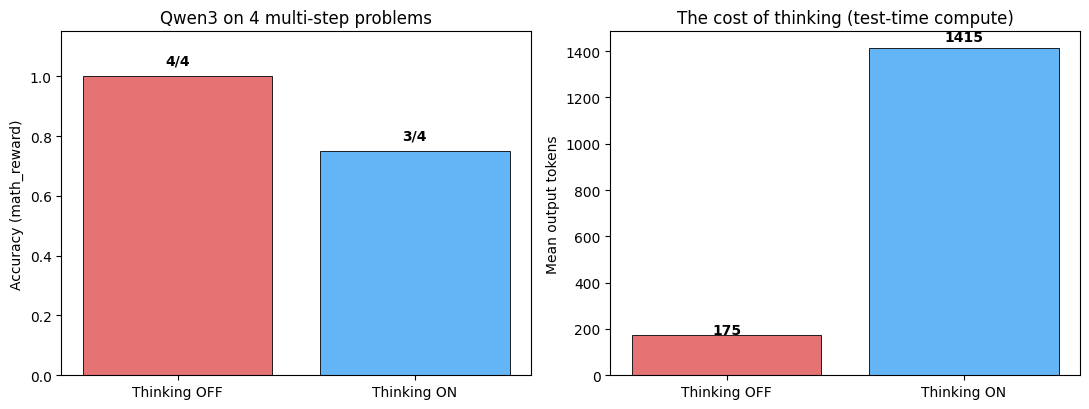

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

labels     = ["Thinking OFF", "Thinking ON"]
counts     = [no_think_correct, think_correct]
accuracies = [c / total for c in counts]
colors     = ["#e57373", "#64b5f6"]      # red = fast/shallow, blue = slow/deep

# --- Left: accuracy ----------------------------------------------------------
bars = ax1.bar(labels, accuracies, color=colors, edgecolor="black", linewidth=0.6)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Accuracy (math_reward)")
ax1.set_title(f"Qwen3 on {total} multi-step problems")
for bar, c in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
             f"{c}/{total}", ha="center", fontweight="bold")

# --- Right: what it cost -----------------------------------------------------
# Accuracy alone is only half the story; this panel is the price tag.
mean_tokens = [np.mean([r["tokens"] for r in no_think_rows]),
               np.mean([r["tokens"] for r in think_rows])]
bars2 = ax2.bar(labels, mean_tokens, color=colors, edgecolor="black", linewidth=0.6)
ax2.set_ylabel("Mean output tokens")
ax2.set_title("The cost of thinking (test-time compute)")
for bar, t in zip(bars2, mean_tokens):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
             f"{t:.0f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## ➡️ Next

We have measured what thinking costs and what it buys. One question is left, and it is the
uncomfortable one:

> **Can we actually trust the reasoning we just paid for?**

---

# ⚠️ Part 7 — Can We Trust the Reasoning Trace?

### 1. CoT is not always faithful
A model can give a convincing explanation **after** being influenced by hidden bias.

> **Visible reasoning ≠ guaranteed true internal reasoning.**

### 2. More thinking does not always mean better accuracy

```text
Easy   → normal LLM may be enough
Medium → reasoning helps ✅
Hard   → both may fail ❌
```

Always check for **token truncation** before blaming reasoning.

### 3. Practical limits

- **Verbose** → more tokens and latency
- **Prompt-sensitive** → wording can change results
- **Expensive** → Self-Consistency / ToT require more compute
- **Verifier ceiling** → RLVR needs a reliable checker
- **Sparse reward** → one final reward judges the whole reasoning trace

> 🔑 **Reasoning traces are useful for inspection, but they are not guaranteed explanations of how the model actually reached its answer.**

# 🎓 Part 8 — Recap, exercises, references

## 🔑 The seven things to remember

1. **The capability is latent; the prompt unlocks it.** 17.7 % → 78.7 % with *zero* weight updates.
   Generated tokens are the model's only scratchpad.
2. **Test-time compute is a real axis.** CoT → self-consistency → ToT is a ladder of increasing
   inference cost buying increasing accuracy, and it saturates.
3. **A verifier is a program, not a network.** That is what makes RLVR unhackable, memory-free, and
   valid however far the policy drifts — and what confines it to checkable domains.
4. **GRPO replaces the critic with the group mean.** Mean-subtraction *is* GRPO; std-division is a
   separate optional stabiliser.
5. **Zero variance in a group means zero gradient.** GRPO ignores problems that are too easy or too
   hard — an emergent curriculum. Watch reward *variance*, not reward *mean*.
6. **GSPO changes the importance ratio, not the advantage.** Token-level ratios with one sample per
   token correct nothing and inject variance that grows with trace length; sequence-level ratios
   shrink it as $\sqrt{L}$.
7. **A reasoning trace is not an audit log.** Models follow biases they never mention.

## 🧪 Exercises

**Easy**
1. Add three questions to `QUESTION_BANK` where the answer is negative or fractional. Does
   `normalize_answer` handle them? Find a case where it doesn't.
2. Set `N_SAMPLES` to 1, 3, 5, 7. Plot majority-vote accuracy against $k$. Where do
   the gains saturate?

**Medium**

3. **Break the verifier deliberately.** Remove the `<think>` strip and re-run Part 6. Quantify how
   many points of accuracy that one line was worth.
4. In `compare_ratios`, vary `drift` from 0.0 to 0.5. At what drift does the token-level estimator's
   noise stop dominating the signal?
5. Implement **weighted** self-consistency: weight each path's vote by its mean token log-probability
   instead of counting votes equally. Does it beat plain majority?

**Hard**

6. Implement the full GRPO clipped surrogate — you have `grpo_advantages`; add the ratio
   $w_{i,t}$ and the clip. Then implement the GSPO version with $s_i(\theta)$ and compare the
   fraction of tokens clipped by each at $\epsilon = 0.2$.
7. Build a **process** reward: score each *line* of a trace, not just the final answer. What
   labelling would you need, and where does it break down?

**Contributed by:** Hussain Alyafei